<a href="https://colab.research.google.com/github/RavinduThamodya/CMA-Air-Pollutant/blob/main/CMA_PM2_5_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install scikit-posthocs

In [4]:
# DATA HANDLING
import pandas as pd
import numpy as np

# VISUALIZATION
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.patches as patches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator
import seaborn as sns

# TIME / UTILITIES
import calendar

# STATISTICAL ANALYSIS
from scipy.stats import kruskal
import scikit_posthocs as sp

In [30]:
file_path = '/content/drive/MyDrive/Air_Quality_Research/Dataset.xlsx'
df = pd.read_excel(file_path)

In [31]:
df['datetime']=pd.to_datetime(df['datetime'], errors='coerce', utc=True)
df['datetime']=df['datetime'].dt.tz_convert('Asia/Colombo')
df['datetime']=df['datetime'].dt.tz_localize(None)
df['datetime'].head(3)

,datetime
0,2025-07-03 15:10:00
1,2025-07-03 15:00:00
2,2025-07-03 14:50:00


In [32]:
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 11
mpl.rcParams['ytick.labelsize'] = 11
mpl.rcParams['axes.titlesize'] = 11
mpl.rcParams['axes.titleweight'] = 'bold'


In [33]:
df=df[
    (df['datetime']>='2023-01-01') &
    (df['datetime'] <'2026-01-01')
]

In [34]:
duplicates = df.duplicated(subset=['Sensor_Id', 'datetime'], keep=False)
print("Number of duplicated rows:", duplicates.sum())

Number of duplicated rows: 309070


In [35]:
df = df.drop_duplicates(subset=['Sensor_Id', 'datetime'], keep='first')

In [36]:
print("Remaining duplicates:", df.duplicated(subset=['Sensor_Id', 'datetime']).sum())

Remaining duplicates: 0


In [37]:
target_sensors = [
    173211,    # Colombo Outdoor 1
    29677,    # Colombo Outdoor 2
    40173,    # Colombo Outdoor 3
    157603    # Colombo Outdoor 4
]

original_row_count = len(df)

df = df[df['Sensor_Id'].isin(target_sensors)].copy()

print(f"Original Row Count: {original_row_count}")
print(f"Final Colombo Outdoor Row Count: {len(df)}")
print(f"Remaining Sensors: {df['Sensor_Id'].unique()}")

Original Row Count: 522343
Final Colombo Outdoor Row Count: 359471
Remaining Sensors: [ 29677  40173 157603 173211]


In [38]:
df

,humidity,temperature,pm2.5_atm,datetime,date,Sensor_Id
117076,62.0,89.0,16.4,2023-04-01 05:20:00,31/03/2023,29677
117077,62.0,89.0,15.5,2023-04-01 05:10:00,31/03/2023,29677
117078,61.0,89.0,15.0,2023-04-01 05:00:00,31/03/2023,29677
117079,61.0,89.0,15.4,2023-04-01 04:50:00,31/03/2023,29677
117080,61.0,90.0,14.2,2023-04-01 04:40:00,31/03/2023,29677
...,...,...,...,...,...,...
817921,63.0,89.0,48.2,2025-12-31 23:10:00,2025-12-31 00:00:00,29677
817922,63.0,89.0,47.1,2025-12-31 23:20:00,2025-12-31 00:00:00,29677
817923,63.0,89.0,47.1,2025-12-31 23:30:00,2025-12-31 00:00:00,29677
817924,63.0,89.0,43.4,2025-12-31 23:40:00,2025-12-31 00:00:00,29677


In [39]:
df.describe()

,humidity,temperature,pm2.5_atm,datetime,Sensor_Id
count,359471.000000,359471.000000,359471.00000,359471,359471.000000
mean,63.701625,90.795232,23.49997,2024-07-30 20:17:50.000640,88131.874463
min,23.000000,78.000000,0.00000,2023-01-01 00:00:00,29677.000000
25%,57.000000,88.000000,8.70000,2023-11-14 03:40:00,29677.000000
50%,63.000000,91.000000,19.00000,2024-08-16 00:10:00,40173.000000
75%,70.000000,93.000000,33.90000,2025-05-25 16:55:00,173211.000000
max,100.000000,109.000000,1728.70000,2025-12-31 23:50:00,173211.000000
std,10.521549,3.845397,23.27665,NaN,66442.755996


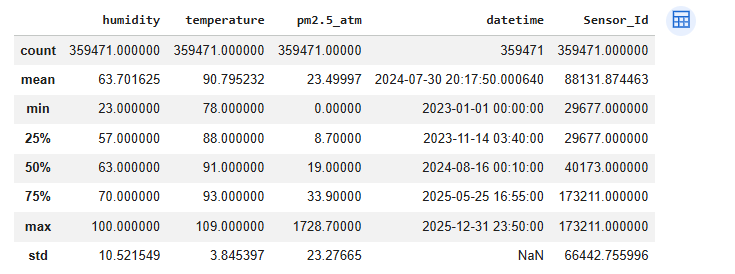

In [24]:
path = '/content/drive/MyDrive/Air_Quality_Research'
df.to_excel(f'{path}/CMA_dataset.xlsx', index=False)

In [97]:
file_path = '/content/drive/MyDrive/Air_Quality_Research/CMA_dataset.xlsx'
df = pd.read_excel(file_path)

In [98]:
# Remove rows where pm2.5_atm is negative or greater than 500
df = df[(df['pm2.5_atm'] >= 0) & (df['pm2.5_atm'] <= 500)]

# Optional: check result
print(df['pm2.5_atm'].describe())

count    359376.000000
mean         23.303199
std          19.409385
min           0.000000
25%           8.700000
50%          18.900000
75%          33.900000
max         494.700000
Name: pm2.5_atm, dtype: float64


In [99]:
df2=df

In [100]:
df2

,humidity,temperature,pm2.5_atm,datetime,date,Sensor_Id
0,62,89,16.4,2023-04-01 05:20:00,31/03/2023,29677
1,62,89,15.5,2023-04-01 05:10:00,31/03/2023,29677
2,61,89,15.0,2023-04-01 05:00:00,31/03/2023,29677
3,61,89,15.4,2023-04-01 04:50:00,31/03/2023,29677
4,61,90,14.2,2023-04-01 04:40:00,31/03/2023,29677
...,...,...,...,...,...,...
359466,63,89,48.2,2025-12-31 23:10:00,2025-12-31 00:00:00,29677
359467,63,89,47.1,2025-12-31 23:20:00,2025-12-31 00:00:00,29677
359468,63,89,47.1,2025-12-31 23:30:00,2025-12-31 00:00:00,29677
359469,63,89,43.4,2025-12-31 23:40:00,2025-12-31 00:00:00,29677


In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [101]:
df_hourly = df.groupby([
    'Sensor_Id',
    pd.Grouper(key='datetime', freq='h')
])['pm2.5_atm'].agg(['mean', 'count']).reset_index()

print(df_hourly.head())

   Sensor_Id            datetime    mean  count
0      29677 2023-01-01 00:00:00  110.25      2
1      29677 2023-01-01 03:00:00   47.00      1
2      29677 2023-01-01 05:00:00   44.90      1
3      29677 2023-01-01 06:00:00   46.40      2
4      29677 2023-01-01 07:00:00   48.95      2


In [102]:
mask = ~df_hourly['count'].between(4, 6)

df_hourly.loc[mask, 'mean'] = pd.NA
print(df_hourly.head(10))

   Sensor_Id            datetime  mean  count
0      29677 2023-01-01 00:00:00   NaN      2
1      29677 2023-01-01 03:00:00   NaN      1
2      29677 2023-01-01 05:00:00   NaN      1
3      29677 2023-01-01 06:00:00   NaN      2
4      29677 2023-01-01 07:00:00   NaN      2
5      29677 2023-01-01 09:00:00   NaN      1
6      29677 2023-01-01 10:00:00   NaN      2
7      29677 2023-01-01 12:00:00   NaN      1
8      29677 2023-01-01 13:00:00   NaN      2
9      29677 2023-01-01 14:00:00   NaN      1


In [103]:
df_hourly.isnull().sum()

,0
Sensor_Id,0
datetime,0
mean,13228
count,0


In [104]:
df_hourly = df_hourly.dropna()

In [105]:
df_hourly.isnull().sum()

,0
Sensor_Id,0
datetime,0
mean,0
count,0


In [106]:
# Extract hour
df_hourly['hour'] = df_hourly['datetime'].dt.hour

# Count number of aggregated hourly records per hour-of-day
hourly_counts = (
    df_hourly
    .groupby('hour')
    .size()
    .reset_index(name='count')
    .sort_values('hour')
)

hourly_counts

,hour,count
0,0,2345
1,1,2346
2,2,2342
3,3,2351
4,4,2344
5,5,2313
6,6,2360
7,7,2370
8,8,2364
9,9,2382


In [107]:
# Extract month name
df_hourly['month'] = df_hourly['datetime'].dt.month_name()

# Month order (important for correct sorting)
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

df_hourly['month'] = pd.Categorical(df_hourly['month'], categories=month_order, ordered=True)

# --- SUMMARY STATISTICS ---
monthly_stats = (
    df_hourly
    .groupby('month')['mean']
    .agg([
        'count',
        'mean',
        lambda x: x.quantile(0.25),
        'median',
        lambda x: x.quantile(0.75)
    ])
    .reset_index()
)

# Rename columns properly
monthly_stats.columns = [
    'month',
    'count',
    'mean',
    'Q1 (25%)',
    'median',
    'Q3 (75%)'
]

# Sort correctly
monthly_stats = monthly_stats.sort_values('month')

monthly_stats

/tmp/ipykernel_7382/2603471512.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('month')['mean']


,month,count,mean,Q1 (25%),median,Q3 (75%)
0,January,4937,33.019522,21.716667,30.566667,40.900000
1,February,6511,39.444948,29.183333,38.783333,46.726667
2,March,5143,37.046780,25.300000,35.583333,46.141667
3,April,3168,25.509512,15.883333,23.858333,32.812500
4,May,3548,17.514584,7.833333,14.333333,24.570833
5,June,4450,13.187316,6.204167,9.916667,16.650000
6,July,5825,11.831917,5.850000,8.333333,13.233333
7,August,5058,11.270648,6.050000,8.641667,12.683333
8,September,4760,10.962621,5.600000,8.383333,13.116667
9,October,4906,16.613270,7.120833,13.100000,22.050000


In [108]:
data = df_hourly['mean'].dropna()

n = len(data)
mean = data.mean()
std = data.std(ddof=1)
se = std / np.sqrt(n)

ci_lower = mean - 1.96 * se
ci_upper = mean + 1.96 * se

summary = data.describe().to_dict()
summary['95% CI Lower'] = ci_lower
summary['95% CI Upper'] = ci_upper

summary_df = pd.DataFrame(summary, index=['value']).T
summary_df

,value
count,56620.000000
mean,23.478597
std,18.281217
min,0.083333
25%,8.933333
50%,19.333333
75%,34.133333
max,356.975000
95% CI Lower,23.328014
95% CI Upper,23.629181


In [109]:
df_hourly['mean'].sem()

np.float64(0.07682811245256961)

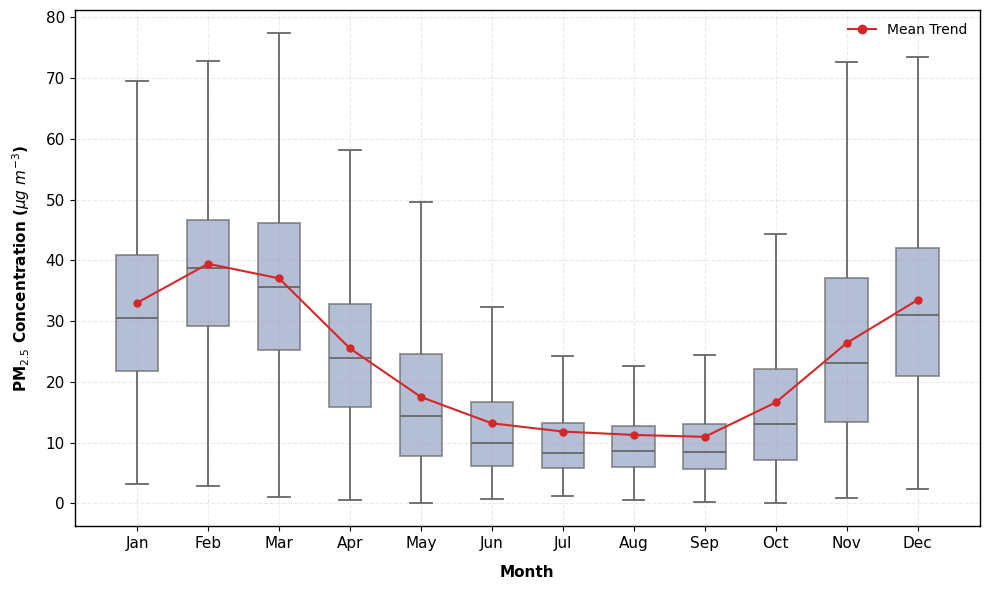

In [110]:
def plot_monthly_cycle(df_hourly):
    # --- 1. DATA PREP ---
    df_hourly['month'] = df_hourly['datetime'].dt.month
    df_hourly['month_name'] = df_hourly['month'].apply(lambda x: calendar.month_abbr[x])

    month_order = list(calendar.month_abbr)[1:]
    df_hourly['month_name'] = pd.Categorical(
        df_hourly['month_name'],
        categories=month_order,
        ordered=True
    )

    # --- 2. FIGURE SETUP ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # --- 3. BOXPLOT (Distribution) ---
    sns.boxplot(
        data=df_hourly,
        x='month_name',
        y='mean',
        order=month_order,
        ax=ax,
        width=0.6,
        linewidth=1.3,         # Thicker lines for print visibility
        color='#8da0cb',       # SOP Standard Blue
        showfliers=False,      # Hidden as per your request
        boxprops={'alpha': 0.7}
    )

    # --- 4. MEAN LINE (Trend) ---
    monthly_means = df_hourly.groupby('month_name', observed=True)['mean'].mean()

    ax.plot(
        month_order,
        monthly_means.reindex(month_order).values,
        color='#d62728',       # SOP Standard Red
        marker='o',
        markersize=5,
        linewidth=1.5,
        label='Mean Value',
        zorder=3
    )

    # --- 5. SOP FORMATTING ---

    # A. Labels (Bold, Size 11)
    ax.set_xlabel('Month', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel(r"PM$_{2.5}$ Concentration ($\mu g~m^{-3}$)", fontsize=11, fontweight='bold', labelpad=10)

    # B. Complete Box Border (Black, All Spines Visible)
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.0)

    # C. Grid
    ax.grid(True, linestyle='--', alpha=0.4, color='#cccccc')

    # --- 6. LEGEND ---
    legend_handle = mlines.Line2D([], [], color='#d62728', marker='o',
                                  markersize=6, linewidth=1.5, label='Mean Trend')

    ax.legend(
        handles=[legend_handle],
        loc='upper right',     # Kept inside the plot frame for compactness
        frameon=False,
        fontsize=10
    )

    # --- 7. LAYOUT ---
    plt.tight_layout()
    plt.show()

# Run the function
plot_monthly_cycle(df_hourly)

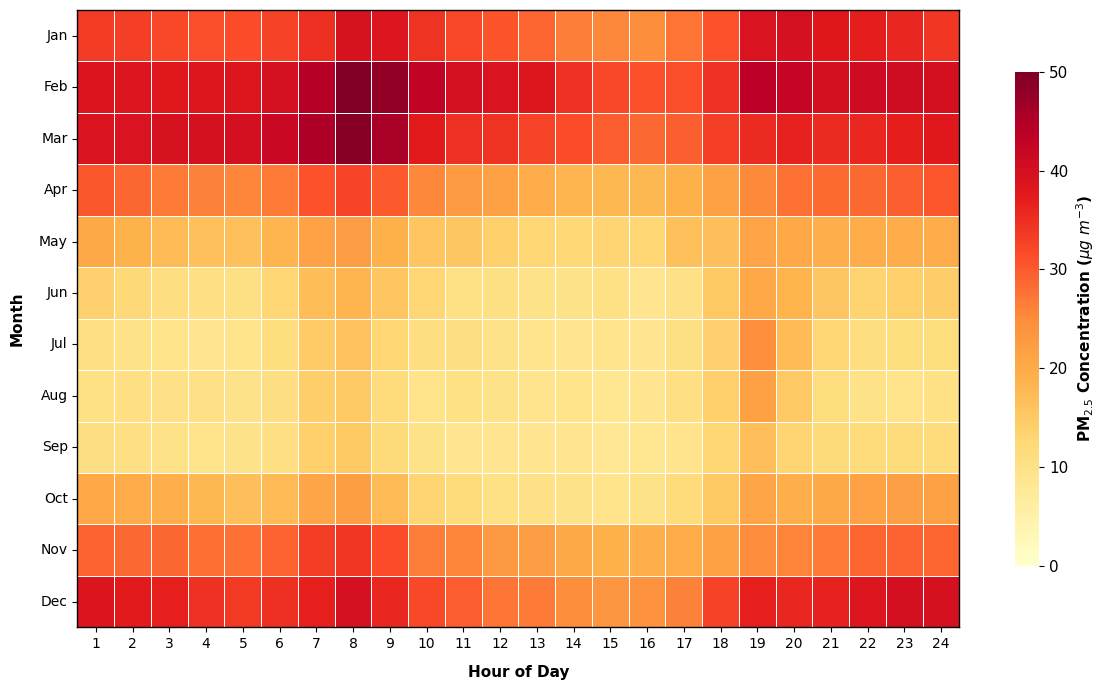

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import calendar

def plot_pollution_heatmap(df_hourly):
    # Compute monthly-hourly mean PM2.5
    heatmap_data = df_hourly.groupby([df_plot['datetime'].dt.month, df_hourly['datetime'].dt.hour])['mean'].mean().unstack()

    # --- 2. FIGURE SETUP ---
    fig, ax = plt.subplots(figsize=(12, 7))

    # --- 3. PLOT HEATMAP ---
    # Sticking to 'YlOrRd' as it is excellent for pollution intensity
    ax = sns.heatmap(
        heatmap_data,
        cmap='YlOrRd',
        annot=False,
        linewidths=0.5,
        linecolor='white',      # Clean grid lines between squares
        vmin=0,
        vmax=50,
        ax=ax,
        cbar_kws={
            'label': r"PM$_{2.5}$ Concentration ($\mu g~m^{-3}$)", # SOP Unit
            'shrink': 0.8       # Shrinks the bar slightly to look neat
        }
    )

    # --- 4. SOP FORMATTING ---

    # A. Axis Titles (Bold, Size 11)
    ax.set_xlabel('Hour of Day', fontsize=11, fontweight='bold', labelpad=10)
    ax.set_ylabel('Month', fontsize=11, fontweight='bold', labelpad=10)

    # B. X-Axis Ticks (Hours 1-24)
    # Note: Pandas hours are 0-23. Your request maps 0->1, 23->24.
    hour_labels = list(range(1, 25))
    ax.set_xticks([i + 0.5 for i in range(24)])
    ax.set_xticklabels(hour_labels, rotation=0, fontsize=10)

    # C. Y-Axis Ticks (Month Names)
    month_labels = [calendar.month_abbr[i] for i in range(1, 13)] # ['Jan', 'Feb'...]
    ax.set_yticks([i + 0.5 for i in range(12)])
    ax.set_yticklabels(month_labels, rotation=0, fontsize=10)

    # D. Colorbar Formatting (Important for SOP)
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_fontweight('bold') # Make the colorbar label BOLD
    cbar.ax.yaxis.label.set_fontsize(11)

    # E. Complete Box Border
    # Heatmaps often hide spines, so we force them on.
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('black')
        ax.spines[spine].set_linewidth(1.0)

    plt.tight_layout()
    plt.show()

# Call function
plot_pollution_heatmap(df_hourly)

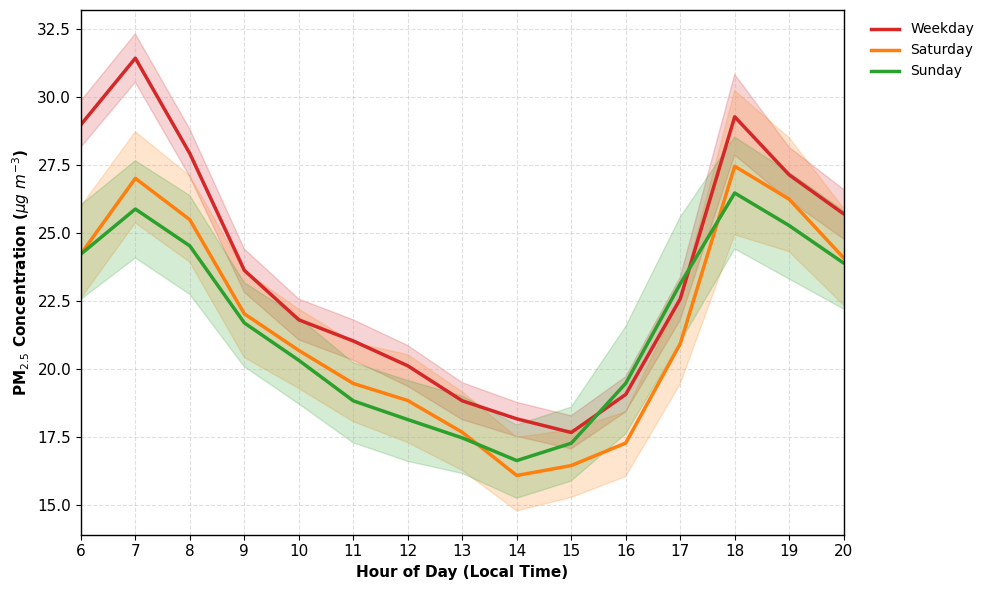

In [113]:
def plot_decoupling_analysis_hourly(df_hourly):
    df_hourly['hour'] = df_hourly['datetime'].dt.hour
    df_hourly['day_type'] = df_hourly['datetime'].dt.day_name().map(
        lambda x: 'Sunday' if x == 'Sunday' else ('Saturday' if x == 'Saturday' else 'Weekday')
    )

    # --- PLOT ---
    plt.figure(figsize=(10, 6))

    sns.lineplot(
        data=df_hourly,
        x='hour',
        y='mean',
        hue='day_type',
        palette={
            'Weekday': '#d62728',
            'Saturday': '#ff7f0e',
            'Sunday': '#2ca02c'
        },
        linewidth=2.5,
        errorbar=('ci', 95)
    )

    # --- FORMATTING ---
    plt.xlabel('Hour of Day (Local Time)', fontsize=11, fontweight='bold')
    plt.ylabel(r"PM$_{2.5}$ Concentration ($\mu g~m^{-3}$)", fontsize=11, fontweight='bold')

    plt.xticks(np.arange(0, 24, 1))
    plt.xlim(6, 20)

    ax = plt.gca()
    for spine in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1.0)

    plt.grid(True, linestyle='--', alpha=0.4)

    plt.legend(
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        frameon=False
    )

    plt.tight_layout()
    plt.show()


# CALL
plot_decoupling_analysis_hourly(df_hourly)

In [114]:
# Step 1 — Convert datetime column
df_hourly['datetime'] = pd.to_datetime(df_hourly['datetime'])

# Step 2 — Extract hour and day of week
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['dayofweek'] = df_hourly['datetime'].dt.dayofweek

# Monday = 0, Tuesday = 1, ..., Saturday = 5, Sunday = 6

# Step 3 — Create group column
def classify_day(x):
    if x <= 4:
        return 'Weekday'
    elif x == 5:
        return 'Saturday'
    else:
        return 'Sunday'

df_hourly['group'] = df_hourly['dayofweek'].apply(classify_day)

# Step 4 — Filter only 07:00 AM data
df_7am = df_hourly[df_hourly['hour'] == 7].copy()

# Step 5 — Extract PM2.5 values for each group
weekday = df_7am[df_7am['group'] == 'Weekday']['mean'].dropna()
saturday = df_7am[df_7am['group'] == 'Saturday']['mean'].dropna()
sunday = df_7am[df_7am['group'] == 'Sunday']['mean'].dropna()

# Step 6 — Check sample sizes
print("Weekday count:", len(weekday))
print("Saturday count:", len(saturday))
print("Sunday count:", len(sunday))

# Step 7 — Run Kruskal-Wallis H Test
stat, p_value = kruskal(weekday, saturday, sunday)

print("\nKruskal-Wallis Test Result")
print("H statistic:", round(stat, 4))
print("p-value:", round(p_value, 6))

# Step 8 — Interpretation
alpha = 0.05

if p_value < alpha:
    print("\nResult: Significant difference exists among Weekday, Saturday, and Sunday PM2.5 at 07:00 AM.")
    print("Next step: Perform Dunn’s Post Hoc Test to identify which groups differ.")
else:
    print("\nResult: No significant difference found among the three groups.")

Weekday count: 1687
Saturday count: 342
Sunday count: 341

Kruskal-Wallis Test Result
H statistic: 33.6302
p-value: 0.0

Result: Significant difference exists among Weekday, Saturday, and Sunday PM2.5 at 07:00 AM.
Next step: Perform Dunn’s Post Hoc Test to identify which groups differ.


In [76]:
dunn_data = df_7am[['mean', 'group']].dropna()

# Dunn's test with Bonferroni correction
dunn_result = sp.posthoc_dunn(
    dunn_data,
    val_col='mean',
    group_col='group',
    p_adjust='bonferroni'
)

print(dunn_result)

          Saturday        Sunday       Weekday
Saturday  1.000000  6.540114e-01  1.199566e-03
Sunday    0.654011  1.000000e+00  8.992070e-07
Weekday   0.001200  8.992070e-07  1.000000e+00


In [77]:
# Step 4 — Filter only 07:00 AM data
df_6pm = df_hourly[df_hourly['hour'] == 18].copy()

# Step 5 — Extract PM2.5 values for each group
weekday = df_6pm[df_6pm['group'] == 'Weekday']['mean'].dropna()
saturday = df_6pm[df_6pm['group'] == 'Saturday']['mean'].dropna()
sunday = df_6pm[df_6pm['group'] == 'Sunday']['mean'].dropna()

# Step 6 — Check sample sizes
print("Weekday count:", len(weekday))
print("Saturday count:", len(saturday))
print("Sunday count:", len(sunday))

# Step 7 — Run Kruskal-Wallis H Test
stat, p_value = kruskal(weekday, saturday, sunday)

print("\nKruskal-Wallis Test Result")
print("H statistic:", round(stat, 4))
print("p-value:", round(p_value, 6))

# Step 8 — Interpretation
alpha = 0.05

if p_value < alpha:
    print("\nResult: Significant difference exists among Weekday, Saturday, and Sunday PM2.5 at 07:00 AM.")
    print("Next step: Perform Dunn’s Post Hoc Test to identify which groups differ.")
else:
    print("\nResult: No significant difference found among the three groups.")

Weekday count: 1677
Saturday count: 333
Sunday count: 338

Kruskal-Wallis Test Result
H statistic: 2.2626
p-value: 0.322617

Result: No significant difference found among the three groups.


In [85]:
# Calculate the means for the 07:00 AM hour
means = df_7am.groupby('group')['mean'].mean()

# 1. Weekday Penalty (vs Sunday)
penalty_sunday = ((means['Weekday'] - means['Sunday']) / means['Sunday']) * 100

# 2. Saturday Transition
penalty_saturday = ((means['Weekday'] - means['Saturday']) / means['Saturday']) * 100


satsun = ((means['Saturday'] - means['Sunday']) / means['Sunday']) * 100

print(f"Workday Penalty (vs Sunday): {penalty_sunday:.2f}%")
print(f"Workday Penalty (vs Saturday): {penalty_saturday:.2f}%")

print(f"sat vs sun: {satsun:.2f}%")

Workday Penalty (vs Sunday): 21.45%
Workday Penalty (vs Saturday): 16.37%
sat vs sun: 4.37%


In [94]:
# Calculate the means for the 07:00 AM hour
means = df_6pm.groupby('group')['mean'].mean()

# 1. Weekday Penalty (vs Sunday)
penalty_sunday = ((means['Weekday'] - means['Sunday']) / means['Sunday']) * 100

# 2. Saturday Transition
penalty_saturday = ((means['Weekday'] - means['Saturday']) / means['Saturday']) * 100


satsun = ((means['Saturday'] - means['Sunday']) / means['Sunday']) * 100

print(f"Workday Penalty (vs Sunday): {penalty_sunday:.2f}%")
print(f"Workday Penalty (vs Saturday): {penalty_saturday:.2f}%")

print(f"sat vs sun: {satsun:.2f}%")

Workday Penalty (vs Sunday): 10.60%
Workday Penalty (vs Saturday): 6.63%
sat vs sun: 3.72%


In [118]:
# Day classification
df_hourly['day_name'] = df_hourly['datetime'].dt.day_name()

def classify_day(day):
    if day == 'Sunday':
        return 'Sunday'
    elif day == 'Saturday':
        return 'Saturday'
    else:
        return 'Weekday'

df_hourly['day_type'] = df_hourly['day_name'].apply(classify_day)

# --- SUMMARY TABLE ---
summary_table = (
    df_hourly
    .groupby(['hour', 'day_type'])['mean']
    .mean()
    .reset_index()
    .pivot(index='hour', columns='day_type', values='mean')
    .sort_index()
    .round(2)
)

# --- FUNCTION TO HIGHLIGHT MAX IN EACH COLUMN ---
def highlight_max(s):
    is_max = s == s.max()
    return ['font-weight: bold' if v else '' for v in is_max]

# Apply styling
styled_table = summary_table.style.apply(highlight_max)

styled_table

day_type,Saturday,Sunday,Weekday
hour,,,
0,23.110000,24.860000,25.350000
1,22.980000,23.630000,24.680000
2,22.540000,23.410000,23.930000
3,21.960000,22.480000,23.240000
4,21.450000,22.320000,23.360000
5,22.010000,22.520000,24.890000
6,24.220000,24.210000,28.970000
7,27.000000,25.870000,31.420000
8,25.480000,24.520000,27.910000
